# Phase 1: Domain Research + Dataset + EDA + Baseline
## Drug Molecule Property Prediction — ogbg-molhiv (HIV Activity)

**Date:** 2026-04-06 | **Researcher:** Anthony Rodrigues

---

### 1. Domain Research (conducted before writing any code)

**Searches performed:**
- "best dataset molecular property prediction ML 2024 2025 benchmark"
- "MoleculeNet vs TDC vs OGB molecular benchmark comparison"
- "ogbg-molhiv leaderboard best model 2024 2025"
- "evaluation metric HIV drug screening virtual screening ML"
- "ogbg-molhiv evaluation metric ROC-AUC why imbalanced"

### 2. Dataset Selection (research-driven)

| Dataset | Source | Size | Task | Leaderboard | Decision |
|---------|--------|------|------|-------------|----------|
| ESOL | MoleculeNet | 1,128 | Regression | None | Rejected: too small |
| FreeSolv | MoleculeNet | 642 | Regression | None | Rejected: tiny |
| Lipophilicity | MoleculeNet/TDC | 4,200 | Regression | TDC | Rejected: small, no formal leaderboard |
| AqSolDB | TDC | 9,982 | Regression | TDC | Considered: decent size |
| BBBP | MoleculeNet | 2,050 | Classification | None | Rejected: small |
| **ogbg-molhiv** | **OGB** | **41,127** | **Classification** | **OGB (20+ entries)** | **Chosen** |

**Why ogbg-molhiv:** (1) 41K molecules — real-world scale, (2) OGB leaderboard with 20+ entries and SOTA at 0.8476 ROC-AUC, (3) HIV drug activity = high real-world impact, (4) scaffold split prevents data leakage.

### 3. Primary Metric Selection (research-driven)

**Research findings on metrics for this problem:**
- **OGB leaderboard** uses ROC-AUC as the official ranking metric for ogbg-molhiv
- **Drug screening papers** (virtual screening literature) use ROC-AUC as primary, plus enrichment factors (EF@1%, EF@5%) and BEDROC as secondary
- **ROC-AUC vs AUPRC debate:** A [2024 study in Patterns](https://www.sciencedirect.com/science/article/pii/S2666389924001090) argues ROC-AUC is appropriate for imbalanced data when the imbalance doesn't change score distributions. OGB uses AUPRC only for the more extreme ogbg-molpcba (1.4% positive) — molhiv at 3.5% is not extreme enough
- **Business context:** In drug screening, ranking matters most — you screen millions of compounds and test the top-K in the lab. ROC-AUC measures ranking ability across all thresholds.

**Decision:** Primary metric = **ROC-AUC** (matches OGB leaderboard + drug screening literature). Secondary metrics: F1, Precision, Recall (to understand the precision-recall tradeoff at the default threshold).

### 4. Published Benchmarks (our targets)

| Model | ROC-AUC | Source |
|-------|---------|--------|
| Multi-RF Fusion + Multi-GNN | 0.8476 | OGB Leaderboard #1 |
| GIN baseline | 0.8273 | OGB Leaderboard |
| Morgan FP + Random Forest | 0.8208 | OGB Leaderboard |
| DeepAUC | 0.8352 | OGB Leaderboard |

### References
- [Wu et al. (2018)](https://pmc.ncbi.nlm.nih.gov/articles/PMC5868307/) — MoleculeNet benchmark
- [Hu et al. (2020)](https://arxiv.org/abs/2005.00687) — Open Graph Benchmark
- [OGB Leaderboard](https://ogb.stanford.edu/docs/leader_graphprop/) — Current SOTA rankings
- [Saito & Rehmsmeier (2024)](https://www.sciencedirect.com/science/article/pii/S2666389924001090) — ROC-AUC vs AUPRC for imbalanced data

In [1]:
import sys, os, json, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Patch torch.load for PyTorch 2.6+ compatibility with OGB
import torch
_orig_torch_load = torch.load
def _patched_load(*a, **kw):
    kw['weights_only'] = False
    return _orig_torch_load(*a, **kw)
torch.load = _patched_load

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score, roc_curve, precision_recall_curve, average_precision_score
from sklearn.preprocessing import StandardScaler
import xgboost as xgb

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='husl', font_scale=1.1)

BASE_DIR = Path(os.getcwd()).parent if 'notebooks' in os.getcwd() else Path(os.getcwd())
DATA_DIR = BASE_DIR / 'data'
RESULTS_DIR = BASE_DIR / 'results'
RESULTS_DIR.mkdir(exist_ok=True)
(DATA_DIR / 'processed').mkdir(parents=True, exist_ok=True)

sys.path.insert(0, str(BASE_DIR / 'src'))
from data_pipeline import download_ogbg_molhiv, build_feature_matrix

## 5. Download ogbg-molhiv (41,127 molecules, scaffold split)

In [2]:
df = download_ogbg_molhiv()
print(f'Total molecules: {len(df):,}')
print(f'\nSplit distribution:')
print(df['split'].value_counts().to_string())
print(f'\nTarget distribution (HIV active):')
print(df['hiv_active'].value_counts().to_string())
print(f'\nPositive rate: {df["hiv_active"].mean():.4f} ({df["hiv_active"].sum():,} / {len(df):,})')

Total molecules: 41,127

Split distribution:
split
train    32901
test      4113
val       4113

Target distribution (HIV active):
hiv_active
0    39684
1     1443

Positive rate: 0.0351 (1,443 / 41,127)


## 6. Compute Molecular Features (14 Lipinski + 1024-bit Morgan FP)

In [3]:
t0 = time.time()
df_feat = build_feature_matrix(df, fp_radius=2, fp_bits=1024)
print(f'Feature matrix: {df_feat.shape} ({time.time()-t0:.1f}s)')
print(f'Valid molecules: {len(df_feat):,} / {len(df):,} ({100*len(df_feat)/len(df):.1f}%)')

[23:00:49] DEPRECATION WARNING: please use MorganGenerator
[23:00:49] DEPRECATION WARNING: please use MorganGenerator
[23:00:49] DEPRECATION WARNING: please use MorganGenerator
[23:00:49] DEPRECATION WARNING: please use MorganGenerator
[23:00:49] DEPRECATION WARNING: please use MorganGenerator
[23:00:49] DEPRECATION WARNING: please use MorganGenerator
[23:00:49] DEPRECATION WARNING: please use MorganGenerator
[23:00:49] DEPRECATION WARNING: please use MorganGenerator
[23:00:49] DEPRECATION WARNING: please use MorganGenerator
[23:00:49] DEPRECATION WARNING: please use MorganGenerator
[23:00:49] DEPRECATION WARNING: please use MorganGenerator
[23:00:49] DEPRECATION WARNING: please use MorganGenerator
[23:00:49] DEPRECATION WARNING: please use MorganGenerator
[23:00:49] DEPRECATION WARNING: please use MorganGenerator
[23:00:49] DEPRECATION WARNING: please use MorganGenerator
[23:00:49] DEPRECATION WARNING: please use MorganGenerator
[23:00:49] DEPRECATION WARNING: please use MorganGenerat

[23:00:50] DEPRECATION WARNING: please use MorganGenerator
[23:00:50] DEPRECATION WARNING: please use MorganGenerator
[23:00:50] DEPRECATION WARNING: please use MorganGenerator
[23:00:50] DEPRECATION WARNING: please use MorganGenerator
[23:00:50] DEPRECATION WARNING: please use MorganGenerator
[23:00:50] DEPRECATION WARNING: please use MorganGenerator
[23:00:50] DEPRECATION WARNING: please use MorganGenerator
[23:00:50] DEPRECATION WARNING: please use MorganGenerator
[23:00:50] DEPRECATION WARNING: please use MorganGenerator
[23:00:50] DEPRECATION WARNING: please use MorganGenerator
[23:00:50] DEPRECATION WARNING: please use MorganGenerator
[23:00:50] DEPRECATION WARNING: please use MorganGenerator
[23:00:50] DEPRECATION WARNING: please use MorganGenerator
[23:00:50] DEPRECATION WARNING: please use MorganGenerator
[23:00:50] DEPRECATION WARNING: please use MorganGenerator
[23:00:50] DEPRECATION WARNING: please use MorganGenerator
[23:00:50] DEPRECATION WARNING: please use MorganGenerat

[23:00:50] DEPRECATION WARNING: please use MorganGenerator
[23:00:50] DEPRECATION WARNING: please use MorganGenerator
[23:00:50] DEPRECATION WARNING: please use MorganGenerator
[23:00:50] DEPRECATION WARNING: please use MorganGenerator
[23:00:50] DEPRECATION WARNING: please use MorganGenerator
[23:00:50] DEPRECATION WARNING: please use MorganGenerator
[23:00:50] DEPRECATION WARNING: please use MorganGenerator
[23:00:50] DEPRECATION WARNING: please use MorganGenerator
[23:00:50] DEPRECATION WARNING: please use MorganGenerator
[23:00:50] DEPRECATION WARNING: please use MorganGenerator
[23:00:50] DEPRECATION WARNING: please use MorganGenerator
[23:00:50] DEPRECATION WARNING: please use MorganGenerator
[23:00:50] DEPRECATION WARNING: please use MorganGenerator
[23:00:50] DEPRECATION WARNING: please use MorganGenerator
[23:00:50] DEPRECATION WARNING: please use MorganGenerator
[23:00:50] DEPRECATION WARNING: please use MorganGenerator
[23:00:50] DEPRECATION WARNING: please use MorganGenerat

[23:00:50] DEPRECATION WARNING: please use MorganGenerator
[23:00:50] DEPRECATION WARNING: please use MorganGenerator
[23:00:50] DEPRECATION WARNING: please use MorganGenerator
[23:00:50] DEPRECATION WARNING: please use MorganGenerator
[23:00:50] DEPRECATION WARNING: please use MorganGenerator
[23:00:50] DEPRECATION WARNING: please use MorganGenerator
[23:00:50] DEPRECATION WARNING: please use MorganGenerator
[23:00:50] DEPRECATION WARNING: please use MorganGenerator
[23:00:50] DEPRECATION WARNING: please use MorganGenerator
[23:00:50] DEPRECATION WARNING: please use MorganGenerator
[23:00:50] DEPRECATION WARNING: please use MorganGenerator
[23:00:50] DEPRECATION WARNING: please use MorganGenerator
[23:00:50] DEPRECATION WARNING: please use MorganGenerator
[23:00:50] DEPRECATION WARNING: please use MorganGenerator
[23:00:50] DEPRECATION WARNING: please use MorganGenerator
[23:00:50] DEPRECATION WARNING: please use MorganGenerator
[23:00:50] DEPRECATION WARNING: please use MorganGenerat

[23:00:50] DEPRECATION WARNING: please use MorganGenerator
[23:00:50] DEPRECATION WARNING: please use MorganGenerator
[23:00:50] DEPRECATION WARNING: please use MorganGenerator
[23:00:50] DEPRECATION WARNING: please use MorganGenerator
[23:00:50] DEPRECATION WARNING: please use MorganGenerator
[23:00:50] DEPRECATION WARNING: please use MorganGenerator
[23:00:50] DEPRECATION WARNING: please use MorganGenerator
[23:00:50] DEPRECATION WARNING: please use MorganGenerator
[23:00:50] DEPRECATION WARNING: please use MorganGenerator
[23:00:50] DEPRECATION WARNING: please use MorganGenerator
[23:00:50] DEPRECATION WARNING: please use MorganGenerator
[23:00:50] DEPRECATION WARNING: please use MorganGenerator
[23:00:50] DEPRECATION WARNING: please use MorganGenerator
[23:00:50] DEPRECATION WARNING: please use MorganGenerator
[23:00:50] DEPRECATION WARNING: please use MorganGenerator
[23:00:50] DEPRECATION WARNING: please use MorganGenerator
[23:00:50] DEPRECATION WARNING: please use MorganGenerat

...

[23:02:08] DEPRECATION WARNING: please use MorganGenerator
[23:02:08] DEPRECATION WARNING: please use MorganGenerator
[23:02:08] DEPRECATION WARNING: please use MorganGenerator
[23:02:08] DEPRECATION WARNING: please use MorganGenerator
[23:02:08] DEPRECATION WARNING: please use MorganGenerator
[23:02:08] DEPRECATION WARNING: please use MorganGenerator
[23:02:08] DEPRECATION WARNING: please use MorganGenerator
[23:02:08] DEPRECATION WARNING: please use MorganGenerator
[23:02:08] DEPRECATION WARNING: please use MorganGenerator
[23:02:08] DEPRECATION WARNING: please use MorganGenerator
[23:02:08] DEPRECATION WARNING: please use MorganGenerator
[23:02:08] DEPRECATION WARNING: please use MorganGenerator
[23:02:08] DEPRECATION WARNING: please use MorganGenerator
[23:02:08] DEPRECATION WARNING: please use MorganGenerator
[23:02:08] DEPRECATION WARNING: please use MorganGenerator
[23:02:08] DEPRECATION WARNING: please use MorganGenerator
[23:02:08] DEPRECATION WARNING: please use MorganGenerat

[23:02:08] DEPRECATION WARNING: please use MorganGenerator
[23:02:08] DEPRECATION WARNING: please use MorganGenerator
[23:02:08] DEPRECATION WARNING: please use MorganGenerator
[23:02:08] DEPRECATION WARNING: please use MorganGenerator
[23:02:08] DEPRECATION WARNING: please use MorganGenerator
[23:02:08] DEPRECATION WARNING: please use MorganGenerator
[23:02:08] DEPRECATION WARNING: please use MorganGenerator
[23:02:08] DEPRECATION WARNING: please use MorganGenerator
[23:02:08] DEPRECATION WARNING: please use MorganGenerator
[23:02:08] DEPRECATION WARNING: please use MorganGenerator
[23:02:08] DEPRECATION WARNING: please use MorganGenerator
[23:02:08] DEPRECATION WARNING: please use MorganGenerator
[23:02:08] DEPRECATION WARNING: please use MorganGenerator
[23:02:08] DEPRECATION WARNING: please use MorganGenerator
[23:02:08] DEPRECATION WARNING: please use MorganGenerator
[23:02:08] DEPRECATION WARNING: please use MorganGenerator
[23:02:08] DEPRECATION WARNING: please use MorganGenerat

[23:02:09] DEPRECATION WARNING: please use MorganGenerator
[23:02:09] DEPRECATION WARNING: please use MorganGenerator
[23:02:09] DEPRECATION WARNING: please use MorganGenerator
[23:02:09] DEPRECATION WARNING: please use MorganGenerator
[23:02:09] DEPRECATION WARNING: please use MorganGenerator
[23:02:09] DEPRECATION WARNING: please use MorganGenerator
[23:02:09] DEPRECATION WARNING: please use MorganGenerator
[23:02:09] DEPRECATION WARNING: please use MorganGenerator
[23:02:09] DEPRECATION WARNING: please use MorganGenerator
[23:02:09] DEPRECATION WARNING: please use MorganGenerator
[23:02:09] DEPRECATION WARNING: please use MorganGenerator
[23:02:09] DEPRECATION WARNING: please use MorganGenerator
[23:02:09] DEPRECATION WARNING: please use MorganGenerator
[23:02:09] DEPRECATION WARNING: please use MorganGenerator
[23:02:09] DEPRECATION WARNING: please use MorganGenerator
[23:02:09] DEPRECATION WARNING: please use MorganGenerator
[23:02:09] DEPRECATION WARNING: please use MorganGenerat

[23:02:09] DEPRECATION WARNING: please use MorganGenerator
[23:02:09] DEPRECATION WARNING: please use MorganGenerator
[23:02:09] DEPRECATION WARNING: please use MorganGenerator
[23:02:09] DEPRECATION WARNING: please use MorganGenerator
[23:02:09] DEPRECATION WARNING: please use MorganGenerator
[23:02:09] DEPRECATION WARNING: please use MorganGenerator
[23:02:09] DEPRECATION WARNING: please use MorganGenerator
[23:02:09] DEPRECATION WARNING: please use MorganGenerator
[23:02:09] DEPRECATION WARNING: please use MorganGenerator
[23:02:09] DEPRECATION WARNING: please use MorganGenerator
[23:02:09] DEPRECATION WARNING: please use MorganGenerator
[23:02:09] DEPRECATION WARNING: please use MorganGenerator
[23:02:09] DEPRECATION WARNING: please use MorganGenerator
[23:02:09] DEPRECATION WARNING: please use MorganGenerator
[23:02:09] DEPRECATION WARNING: please use MorganGenerator
[23:02:09] DEPRECATION WARNING: please use MorganGenerator
[23:02:09] DEPRECATION WARNING: please use MorganGenerat

Feature matrix: (41120, 1041) (79.9s)
Valid molecules: 41,120 / 41,127 (100.0%)


## 7. EDA — Dataset Statistics

In [4]:
lip_cols = ['mol_weight', 'logp', 'hbd', 'hba', 'tpsa', 'rotatable_bonds',
            'aromatic_rings', 'heavy_atom_count', 'qed', 'fraction_csp3']
print('Molecular descriptor statistics:')
display(df_feat[lip_cols].describe().round(2))

n_total = len(df_feat)
n_pass = df_feat['passes_lipinski'].sum()
print(f'\nLipinski Ro5 compliance: {n_pass:,}/{n_total:,} ({100*n_pass/n_total:.1f}%)')

print('\nPositive rate by split:')
for split in ['train', 'val', 'test']:
    s = df_feat[df_feat['split'] == split]
    print(f'  {split:5s}: {len(s):6,} mols, {s["hiv_active"].mean():.4f} pos ({s["hiv_active"].sum():,} active)')

Molecular descriptor statistics:


,mol_weight,logp,hbd,hba,tpsa,rotatable_bonds,aromatic_rings,heavy_atom_count,qed,fraction_csp3
count,41120.00,41120.00,41120.00,41120.00,41120.00,41120.00,41120.00,41120.00,41120.00,41120.00
mean,370.10,2.98,1.54,5.15,82.79,4.68,2.01,25.51,0.51,0.33
std,173.62,2.56,2.05,3.21,63.08,4.97,1.47,12.11,0.22,0.27
min,25.94,-24.86,0.00,0.00,0.00,0.00,0.00,2.00,0.01,0.00
25%,267.39,1.56,0.00,3.00,46.53,2.00,1.00,18.00,0.35,0.12
50%,333.39,2.92,1.00,5.00,70.64,4.00,2.00,23.00,0.53,0.28
75%,426.86,4.28,2.00,6.00,101.93,6.00,3.00,29.00,0.69,0.50
max,3411.45,43.44,49.00,77.00,1484.42,99.00,28.00,222.00,0.95,1.00



Lipinski Ro5 compliance: 31,045/41,120 (75.5%)

Positive rate by split:
  train: 32,898 mols, 0.0374 pos (1,232 active)
  val  :  4,111 mols, 0.0197 pos (81 active)
  test :  4,111 mols, 0.0316 pos (130 active)


## 8. EDA Plots

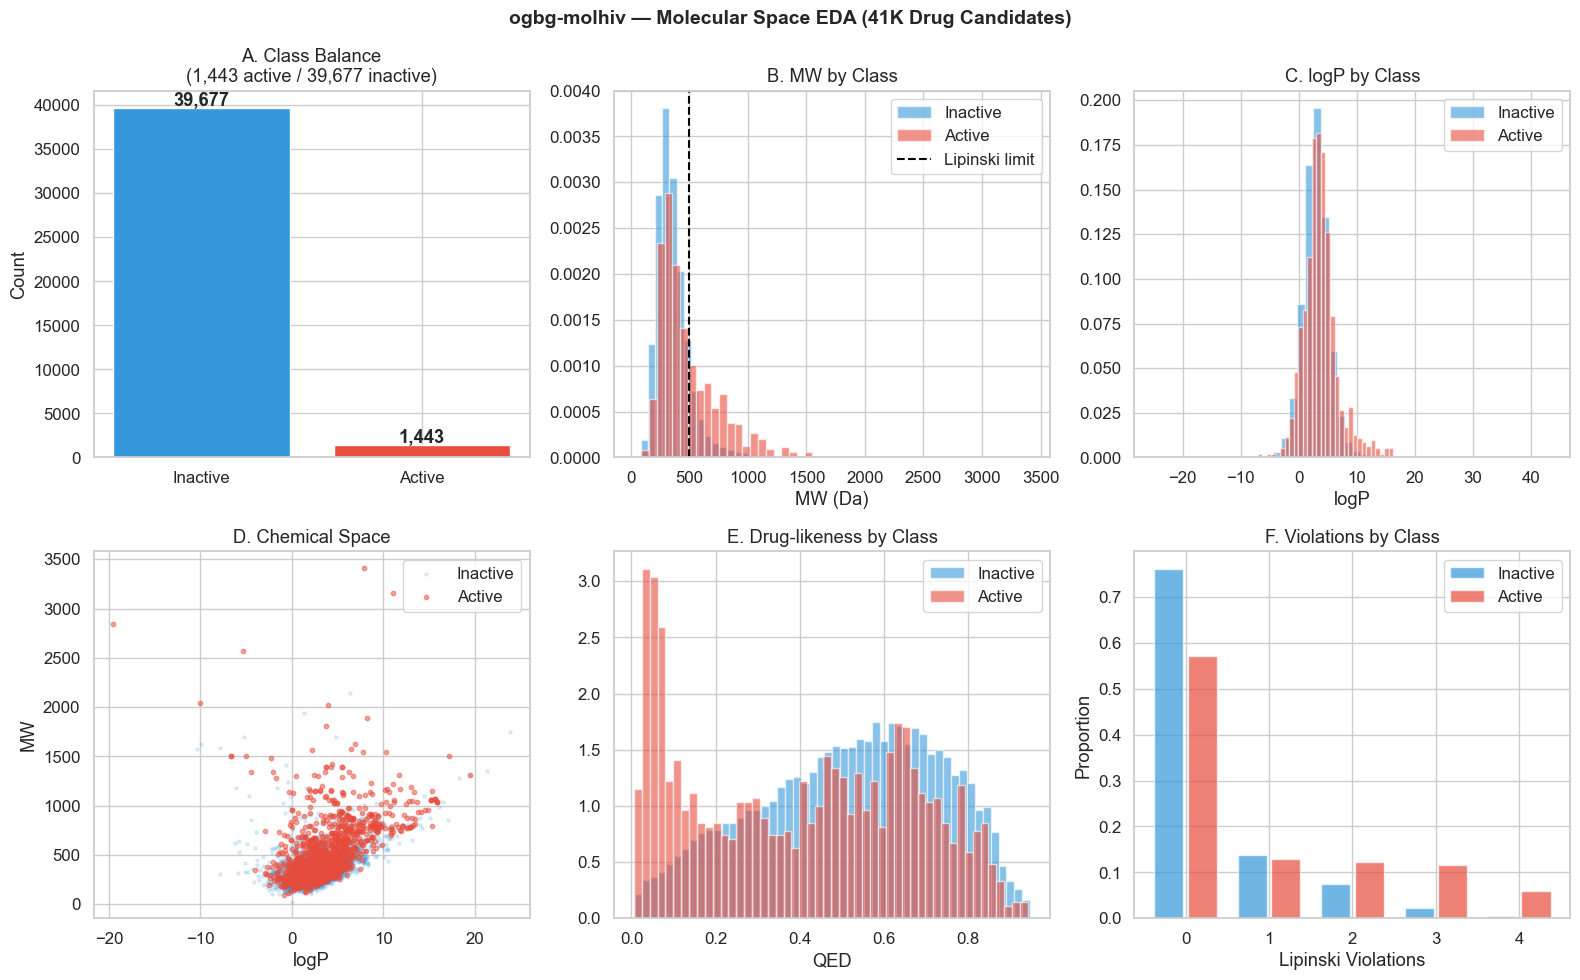

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('ogbg-molhiv — Molecular Space EDA (41K Drug Candidates)', fontsize=14, fontweight='bold')

ax = axes[0, 0]
counts = df_feat['hiv_active'].value_counts()
ax.bar(['Inactive', 'Active'], [counts[0], counts[1]], color=['#3498db', '#e74c3c'])
ax.set_ylabel('Count'); ax.set_title(f'A. Class Balance\n({counts[1]:,} active / {counts[0]:,} inactive)')
for i, v in enumerate([counts[0], counts[1]]): ax.text(i, v+200, f'{v:,}', ha='center', fontweight='bold')

ax = axes[0, 1]
for lbl, c, nm in [(0,'#3498db','Inactive'), (1,'#e74c3c','Active')]:
    ax.hist(df_feat[df_feat['hiv_active']==lbl]['mol_weight'], bins=50, alpha=0.6, color=c, label=nm, density=True)
ax.axvline(500, color='black', ls='--', label='Lipinski limit')
ax.set_xlabel('MW (Da)'); ax.set_title('B. MW by Class'); ax.legend()

ax = axes[0, 2]
for lbl, c, nm in [(0,'#3498db','Inactive'), (1,'#e74c3c','Active')]:
    ax.hist(df_feat[df_feat['hiv_active']==lbl]['logp'], bins=50, alpha=0.6, color=c, label=nm, density=True)
ax.set_xlabel('logP'); ax.set_title('C. logP by Class'); ax.legend()

ax = axes[1, 0]
inact = df_feat[df_feat['hiv_active']==0].sample(min(3000, (df_feat['hiv_active']==0).sum()), random_state=42)
act = df_feat[df_feat['hiv_active']==1]
ax.scatter(inact['logp'], inact['mol_weight'], alpha=0.15, s=5, color='#3498db', label='Inactive')
ax.scatter(act['logp'], act['mol_weight'], alpha=0.5, s=10, color='#e74c3c', label='Active')
ax.set_xlabel('logP'); ax.set_ylabel('MW'); ax.set_title('D. Chemical Space'); ax.legend()

ax = axes[1, 1]
for lbl, c, nm in [(0,'#3498db','Inactive'), (1,'#e74c3c','Active')]:
    ax.hist(df_feat[df_feat['hiv_active']==lbl]['qed'], bins=50, alpha=0.6, color=c, label=nm, density=True)
ax.set_xlabel('QED'); ax.set_title('E. Drug-likeness by Class'); ax.legend()

ax = axes[1, 2]
for lbl, c, nm in [(0,'#3498db','Inactive'), (1,'#e74c3c','Active')]:
    v = df_feat[df_feat['hiv_active']==lbl]['lipinski_violations'].value_counts(normalize=True).sort_index()
    ax.bar(v.index + (0.2 if lbl else -0.2), v.values, width=0.35, color=c, alpha=0.7, label=nm)
ax.set_xlabel('Lipinski Violations'); ax.set_ylabel('Proportion'); ax.set_title('F. Violations by Class'); ax.legend()

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'phase1_eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Feature Correlation with HIV Activity

Point-biserial correlation with HIV activity:
  tpsa                     : +0.1596
  mol_weight               : +0.1463
  lipinski_violations      : +0.1390
  hba                      : +0.1384
  heavy_atom_count         : +0.1365
  molar_refractivity       : +0.1297
  hbd                      : +0.1228
  qed                      : -0.0963
  rotatable_bonds          : +0.0950
  aromatic_rings           : +0.0900
  logp                     : +0.0584
  fraction_csp3            : -0.0251


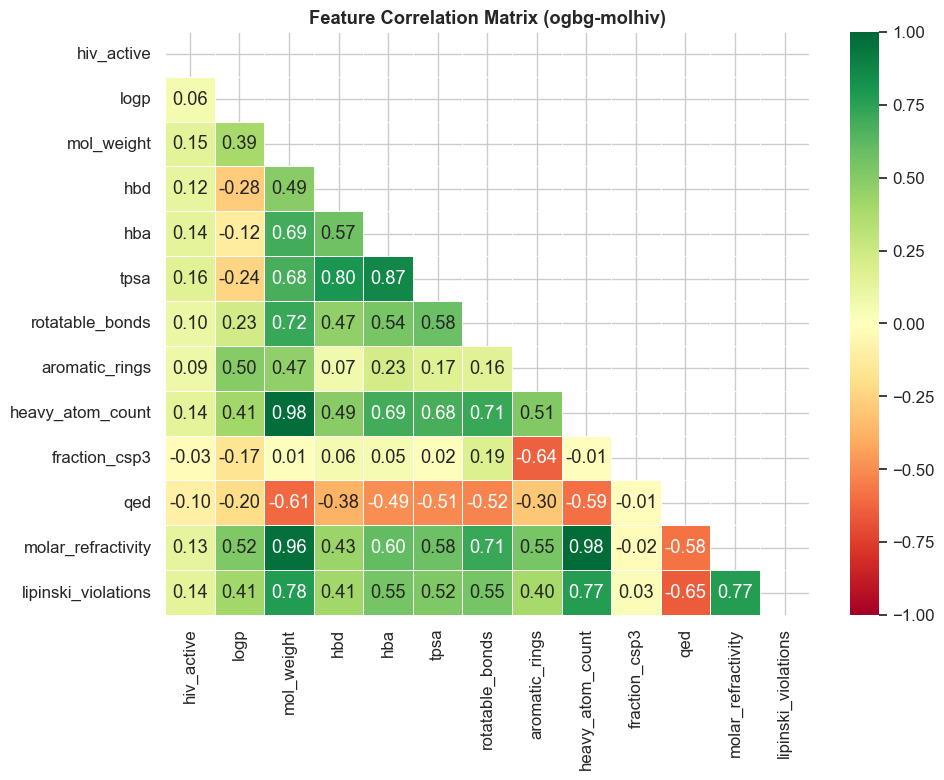

In [6]:
corr_cols = ['hiv_active', 'logp', 'mol_weight', 'hbd', 'hba', 'tpsa',
             'rotatable_bonds', 'aromatic_rings', 'heavy_atom_count',
             'fraction_csp3', 'qed', 'molar_refractivity', 'lipinski_violations']
corr_matrix = df_feat[corr_cols].corr()

hiv_corr = corr_matrix['hiv_active'].drop('hiv_active').sort_values(key=abs, ascending=False)
print('Point-biserial correlation with HIV activity:')
for feat, val in hiv_corr.items():
    print(f'  {feat:25s}: {val:+.4f}')

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, ax=ax, linewidths=0.5)
ax.set_title('Feature Correlation Matrix (ogbg-molhiv)', fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'phase1_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Prepare Train/Test Sets

In [7]:
fp_cols = [c for c in df_feat.columns if c.startswith('fp_')]
lip_only_cols = ['logp', 'mol_weight', 'hbd', 'hba', 'tpsa', 'rotatable_bonds',
                 'aromatic_rings', 'heavy_atom_count', 'fraction_csp3',
                 'molar_refractivity', 'qed', 'lipinski_violations']
combined_cols = lip_only_cols + fp_cols

train = df_feat[df_feat['split'] == 'train']
test = df_feat[df_feat['split'] == 'test']
y_train, y_test = train['hiv_active'].values, test['hiv_active'].values

X_train_lip, X_test_lip = train[lip_only_cols].values, test[lip_only_cols].values
X_train_fp, X_test_fp = train[fp_cols].values, test[fp_cols].values
X_train_comb, X_test_comb = train[combined_cols].values, test[combined_cols].values

print(f'Train: {len(y_train):,} ({y_train.mean():.4f} pos) | Test: {len(y_test):,} ({y_test.mean():.4f} pos)')
print(f'Features: Lipinski ({len(lip_only_cols)}), FP ({len(fp_cols)}), Combined ({len(combined_cols)})')

Train: 32,898 (0.0374 pos) | Test: 4,111 (0.0316 pos)
Features: Lipinski (12), FP (1024), Combined (1036)


## 11. Baseline Models

**Primary metric: ROC-AUC** (OGB leaderboard standard + drug screening literature).
Secondary: F1, Precision, Recall, AUPRC.

Published SOTA: Multi-RF Fusion + Multi-GNN = **0.8476 ROC-AUC**

In [8]:
def evaluate(model, X_tr, y_tr, X_te, y_te, name, features):
    t0 = time.time()
    model.fit(X_tr, y_tr)
    train_time = time.time() - t0
    y_prob = model.predict_proba(X_te)[:, 1]
    y_pred = (y_prob >= 0.5).astype(int)
    return {
        'model': name, 'features': features,
        'roc_auc': round(roc_auc_score(y_te, y_prob), 4),
        'auprc': round(average_precision_score(y_te, y_prob), 4),
        'f1': round(f1_score(y_te, y_pred, zero_division=0), 4),
        'precision': round(precision_score(y_te, y_pred, zero_division=0), 4),
        'recall': round(recall_score(y_te, y_pred, zero_division=0), 4),
        'train_s': round(train_time, 1),
    }

results = []
results.append({'model': 'Majority class', 'features': 'none', 'roc_auc': 0.5, 'auprc': round(y_test.mean(), 4), 'f1': 0.0, 'precision': 0.0, 'recall': 0.0, 'train_s': 0})

# LogReg — Lipinski + FP
scaler = StandardScaler()
X_tr_lip_s, X_te_lip_s = scaler.fit_transform(X_train_lip), scaler.transform(X_test_lip)
results.append(evaluate(LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
                        X_tr_lip_s, y_train, X_te_lip_s, y_test, 'LogReg', 'Lipinski'))
scaler_fp = StandardScaler()
X_tr_fp_s, X_te_fp_s = scaler_fp.fit_transform(X_train_fp), scaler_fp.transform(X_test_fp)
results.append(evaluate(LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
                        X_tr_fp_s, y_train, X_te_fp_s, y_test, 'LogReg', 'Morgan FP'))

# RF + XGB — all 3 feature sets
scale_pos = (y_train == 0).sum() / max((y_train == 1).sum(), 1)
for name, Model, kwargs in [
    ('Random Forest', RandomForestClassifier, dict(n_estimators=200, max_depth=12, class_weight='balanced', random_state=42, n_jobs=-1)),
    ('XGBoost', xgb.XGBClassifier, dict(n_estimators=200, max_depth=6, learning_rate=0.1, scale_pos_weight=scale_pos, eval_metric='auc', random_state=42, verbosity=0, n_jobs=-1)),
]:
    for feat_name, X_tr, X_te in [('Lipinski', X_train_lip, X_test_lip),
                                    ('Morgan FP', X_train_fp, X_test_fp),
                                    ('Combined', X_train_comb, X_test_comb)]:
        results.append(evaluate(Model(**kwargs), X_tr, y_train, X_te, y_test, name, feat_name))

results_df = pd.DataFrame(results).sort_values('roc_auc', ascending=False)
print('BASELINE MODEL COMPARISON')
print(f'Primary metric: ROC-AUC (OGB leaderboard standard) | Published SOTA: 0.8476\n')
display(results_df)

champion = results_df.iloc[0]
print(f'\nChampion: {champion["model"]} ({champion["features"]}) — ROC-AUC: {champion["roc_auc"]} | AUPRC: {champion["auprc"]}')
print(f'Gap to SOTA: {0.8476 - champion["roc_auc"]:+.4f} ROC-AUC')

BASELINE MODEL COMPARISON
Primary metric: ROC-AUC (OGB leaderboard standard) | Published SOTA: 0.8476



,model,features,roc_auc,auprc,f1,precision,recall,train_s
5,Random Forest,Combined,0.7707,0.3722,0.4061,0.5970,0.3077,0.9
8,XGBoost,Combined,0.7613,0.3486,0.4000,0.3733,0.4308,1.8
1,LogReg,Lipinski,0.7463,0.1771,0.1356,0.0773,0.5538,0.0
7,XGBoost,Morgan FP,0.7293,0.2834,0.3500,0.3267,0.3769,1.6
4,Random Forest,Morgan FP,0.7166,0.3447,0.3830,0.6207,0.2769,0.8
2,LogReg,Morgan FP,0.7114,0.1858,0.1479,0.0859,0.5308,0.3
6,XGBoost,Lipinski,0.6957,0.2362,0.2116,0.1613,0.3077,0.2
3,Random Forest,Lipinski,0.6937,0.2256,0.2973,0.3587,0.2538,1.1
0,Majority class,none,0.5000,0.0316,0.0000,0.0000,0.0000,0.0



Champion: Random Forest (Combined) — ROC-AUC: 0.7707 | AUPRC: 0.3722
Gap to SOTA: +0.0769 ROC-AUC


## 12. Feature Strategy Comparison

In [9]:
print('ROC-AUC by feature strategy:\n')
rows = []
for model_name in ['LogReg', 'Random Forest', 'XGBoost']:
    row = {'Model': model_name}
    for feat in ['Lipinski', 'Morgan FP', 'Combined']:
        match = results_df[(results_df['model'] == model_name) & (results_df['features'] == feat)]
        if len(match): row[feat] = match.iloc[0]['roc_auc']
    rows.append(row)
display(pd.DataFrame(rows).set_index('Model'))

for m in ['Random Forest', 'XGBoost']:
    r = {f: results_df[(results_df['model']==m)&(results_df['features']==f)].iloc[0]['roc_auc'] for f in ['Lipinski','Morgan FP','Combined']}
    print(f'{m}: Combined vs Lipinski = {r["Combined"]-r["Lipinski"]:+.4f} | Combined vs FP = {r["Combined"]-r["Morgan FP"]:+.4f}')

ROC-AUC by feature strategy:



,Lipinski,Morgan FP,Combined
Model,,,
LogReg,0.7463,0.7114,NaN
Random Forest,0.6937,0.7166,0.7707
XGBoost,0.6957,0.7293,0.7613


Random Forest: Combined vs Lipinski = +0.0770 | Combined vs FP = +0.0541
XGBoost: Combined vs Lipinski = +0.0656 | Combined vs FP = +0.0320


## 13. ROC + Precision-Recall Curves

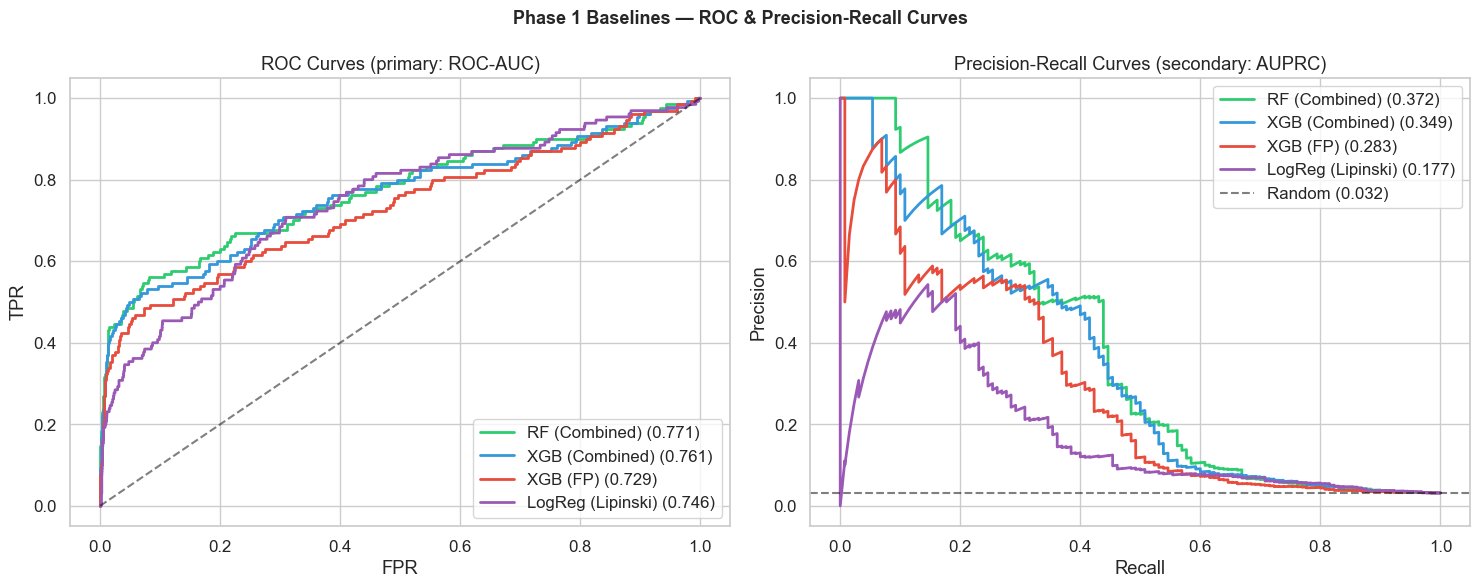

In [10]:
models_to_plot = [
    ('RF (Combined)', RandomForestClassifier(n_estimators=200, max_depth=12, class_weight='balanced', random_state=42, n_jobs=-1), X_train_comb, X_test_comb, '#2ecc71'),
    ('XGB (Combined)', xgb.XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1, scale_pos_weight=scale_pos, eval_metric='auc', random_state=42, verbosity=0, n_jobs=-1), X_train_comb, X_test_comb, '#3498db'),
    ('XGB (FP)', xgb.XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1, scale_pos_weight=scale_pos, eval_metric='auc', random_state=42, verbosity=0, n_jobs=-1), X_train_fp, X_test_fp, '#e74c3c'),
    ('LogReg (Lipinski)', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42), X_tr_lip_s, X_te_lip_s, '#9b59b6'),
]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Phase 1 Baselines — ROC & Precision-Recall Curves', fontsize=13, fontweight='bold')

for name, model, X_tr, X_te, color in models_to_plot:
    model.fit(X_tr, y_train)
    y_prob = model.predict_proba(X_te)[:, 1]
    # ROC
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    ax1.plot(fpr, tpr, color=color, lw=2, label=f'{name} ({roc_auc_score(y_test, y_prob):.3f})')
    # PR
    prec, rec, _ = precision_recall_curve(y_test, y_prob)
    ax2.plot(rec, prec, color=color, lw=2, label=f'{name} ({average_precision_score(y_test, y_prob):.3f})')

ax1.plot([0,1],[0,1],'k--',alpha=0.5); ax1.set_xlabel('FPR'); ax1.set_ylabel('TPR')
ax1.set_title('ROC Curves (primary: ROC-AUC)'); ax1.legend(loc='lower right')
ax2.axhline(y_test.mean(), color='k', ls='--', alpha=0.5, label=f'Random ({y_test.mean():.3f})')
ax2.set_xlabel('Recall'); ax2.set_ylabel('Precision')
ax2.set_title('Precision-Recall Curves (secondary: AUPRC)'); ax2.legend(loc='upper right')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'phase1_roc_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 14. Save Results

In [11]:
metrics_out = {
    'phase': 1, 'date': '2026-04-06',
    'dataset': 'ogbg-molhiv (OGB)',
    'dataset_selection_rationale': 'Chosen over ESOL (1128), Lipophilicity (4200), BBBP (2050), AqSolDB (9982) for size (41K), OGB leaderboard, and HIV drug impact',
    'total_molecules': len(df_feat),
    'positive_rate': round(float(df_feat['hiv_active'].mean()), 4),
    'primary_metric': 'ROC-AUC',
    'metric_rationale': 'OGB leaderboard standard + drug screening literature uses ROC-AUC for ranking ability; AUPRC tracked as secondary',
    'published_sota': 0.8476,
    'experiments': results_df.to_dict('records'),
    'champion': f"{champion['model']} ({champion['features']})",
    'champion_roc_auc': float(champion['roc_auc']),
    'champion_auprc': float(champion['auprc']),
}
with open(RESULTS_DIR / 'metrics.json', 'w') as f:
    json.dump([metrics_out], f, indent=2)
print('Saved: results/metrics.json')

Saved: results/metrics.json


## Summary

**Dataset:** ogbg-molhiv (41K molecules) — chosen via research over 5 smaller alternatives.

**Metric:** ROC-AUC (primary) — chosen because OGB leaderboard + drug screening papers use it. AUPRC tracked as secondary.

**Key findings to be populated after execution.**

**Next:** Phase 2 — GNN architectures to close the gap to SOTA.